# Stochastic Gradient Descent (SGDRegressor) Model
Dataset: [UCI Automobile](https://archive.ics.uci.edu/dataset/10/automobile)

This file focuses on the **SGDRegressor** library from _Scikit-learn_ (aka Stochastic Gradient Descent)

In [1]:
!pip install ucimlrepo

In [34]:
from ucimlrepo import fetch_ucirepo # importing database

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

## 1. Project and Dataset Selection
From the UC Irvine ML Repo, we've selected the automobile dataset to use in targetting

In [11]:
# Fetching database
automobile = fetch_ucirepo(id=10) # id=10 is UCI ML Repo's ID for Automobile dataset


## 2. Regression Model Building

In this section, we'll be performing data pre-processing, loading, model creation and results analysis. This sections focuses on the SGDRegressor (aka Gradient Descent)

### 2.1. Pre-Processing
In this step, we are pre-processing the data from the previously instantiated public URL from the [Automobile UCI ML Repo](https://archive.ics.uci.edu/dataset/10/automobile)

In [ ]:
### 2.1.1. Loading data into Pandas DataFrame 

x = automobile.data.features
y = automobile.data.targets

automobile_df = x.copy()
automobile_df['price'] = y

print (x.shape, y.shape, automobile_df.shape)
automobile_df.head()

(205, 25) (205, 1) (205, 25)


,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,...,length,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses
0,3,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
1,3,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
2,1,26,19,5000.0,154.0,9.0,3.47,2.68,mpfi,152,...,171.2,94.5,front,rwd,hatchback,2.0,std,gas,alfa-romero,NaN
3,2,30,24,5500.0,102.0,10.0,3.40,3.19,mpfi,109,...,176.6,99.8,front,fwd,sedan,4.0,std,gas,audi,164.0
4,2,22,18,5500.0,115.0,8.0,3.40,3.19,mpfi,136,...,176.6,99.4,front,4wd,sedan,4.0,std,gas,audi,164.0


In [ ]:
### 2.1.2. Examining data for consistency (check for NULLs, missing data, etc.) before proceeding to next step
automobile_df.isna().sum() # Checking for any NULL values

## Handling missing values
fill_values = automobile_df.mean(numeric_only=True)
fill_values['num-of-doors'] = automobile_df['num-of-doors'].mode()[0]
automobile_df = automobile_df.fillna(fill_values)

automobile_df.isna().sum()

price                0
highway-mpg          0
city-mpg             0
peak-rpm             0
horsepower           0
compression-ratio    0
stroke               0
bore                 0
fuel-system          0
engine-size          0
num-of-cylinders     0
engine-type          0
curb-weight          0
height               0
width                0
length               0
wheel-base           0
engine-location      0
drive-wheels         0
body-style           0
num-of-doors         0
aspiration           0
fuel-type            0
make                 0
normalized-losses    0
dtype: int64

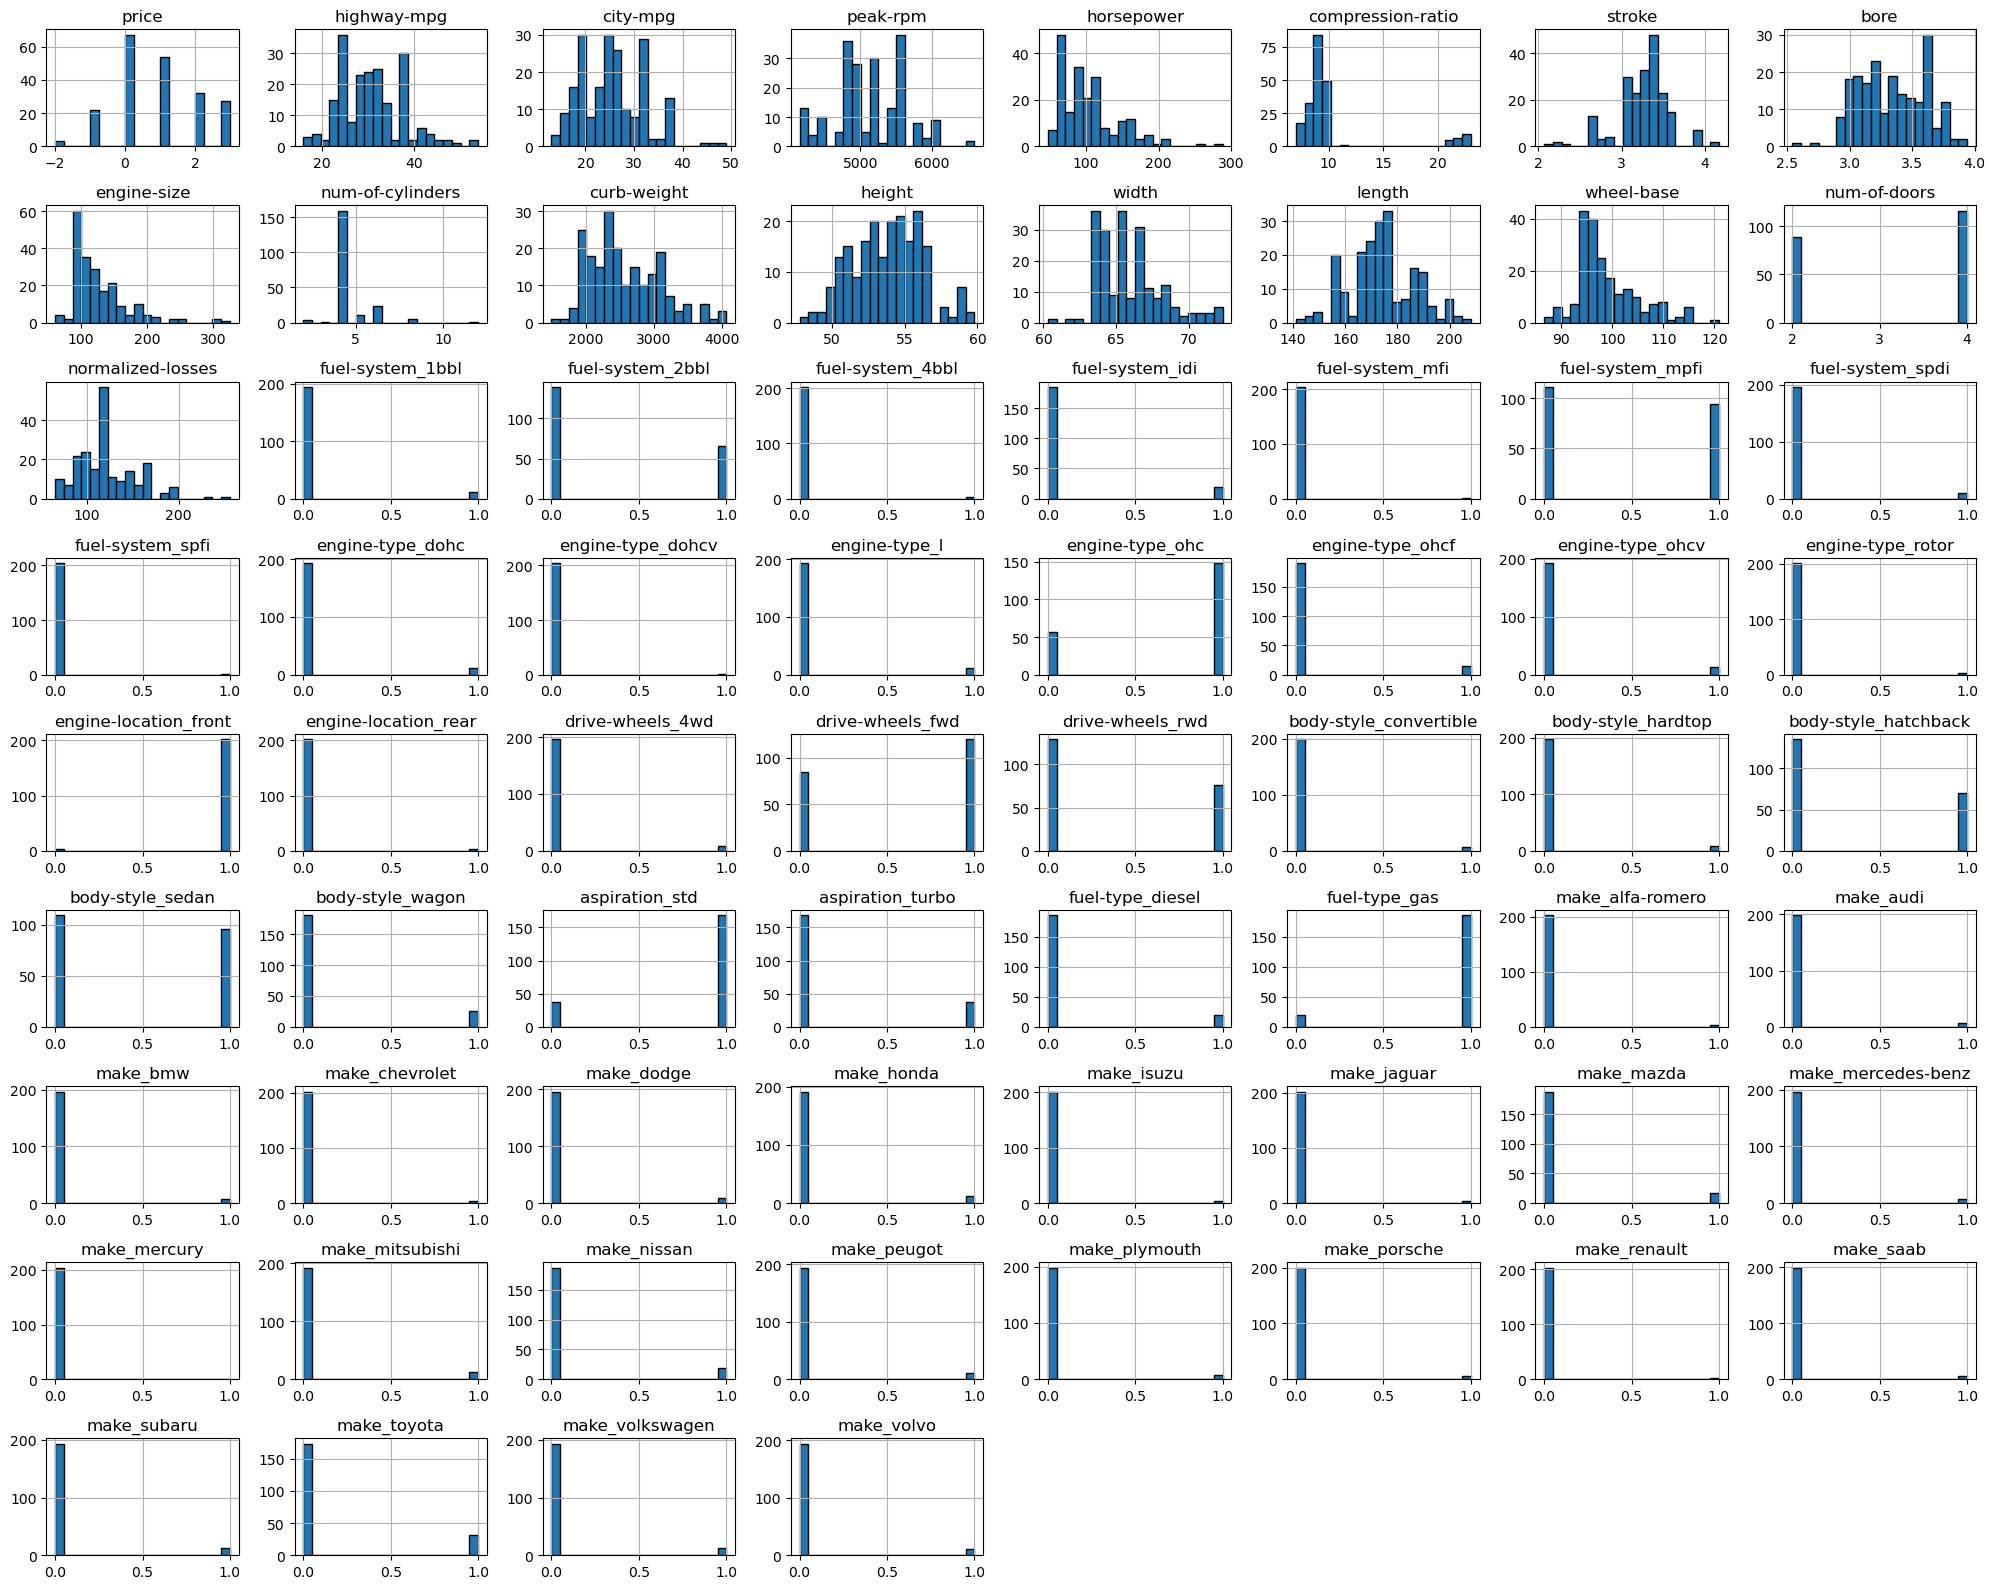

In [ ]:
### 2.1.3. Exaimining attibutes and target varaible(s)

## Understanding the attributes (data types)
automobile_df.dtypes

## Converting categorical attributes to numerical (OneHotEncoder)
automobile_df = pd.get_dummies(automobile_df, dtype=float)
automobile_df.head()

## Obtain and output summery of attributes
automobile_df.describe()


## Addressing if attributes are distributed normally
automobile_df.select_dtypes(include='number').hist(bins=20, edgecolor='black', figsize=(20, 16))
plt.tight_layout()
plt.show()

In [ ]:
### 2.1.4. Standardize and normalize the attributes
y = automobile_df['price']
x = automobile_df.drop('price', axis=1)

## Standardized: Mean 0, Variance 1
x_std = pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns)
x_std.describe()

## Normalize: rescale to a 0-1 range
x_norm = pd.DataFrame(MinMaxScaler().fit_transform(x), columns=x.columns)
x_norm.describe()

,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,engine-size,num-of-cylinders,curb-weight,...,make_nissan,make_peugot,make_plymouth,make_porsche,make_renault,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,...,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.388190,0.339431,0.398110,0.234401,0.196409,0.564487,0.564108,0.248707,0.238049,0.414106,...,0.087805,0.053659,0.034146,0.024390,0.009756,0.029268,0.058537,0.156098,0.058537,0.053659
std,0.181222,0.181726,0.194685,0.164663,0.248253,0.149332,0.193460,0.157142,0.108085,0.201971,...,0.283704,0.225894,0.182050,0.154635,0.098531,0.168970,0.235330,0.363836,0.235330,0.225894
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.236842,0.166667,0.265306,0.091667,0.100000,0.495238,0.435714,0.135849,0.200000,0.254849,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.368421,0.305556,0.428571,0.195833,0.125000,0.580952,0.550000,0.222642,0.200000,0.359193,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.473684,0.472222,0.551020,0.283333,0.150000,0.638095,0.742857,0.301887,0.200000,0.561288,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


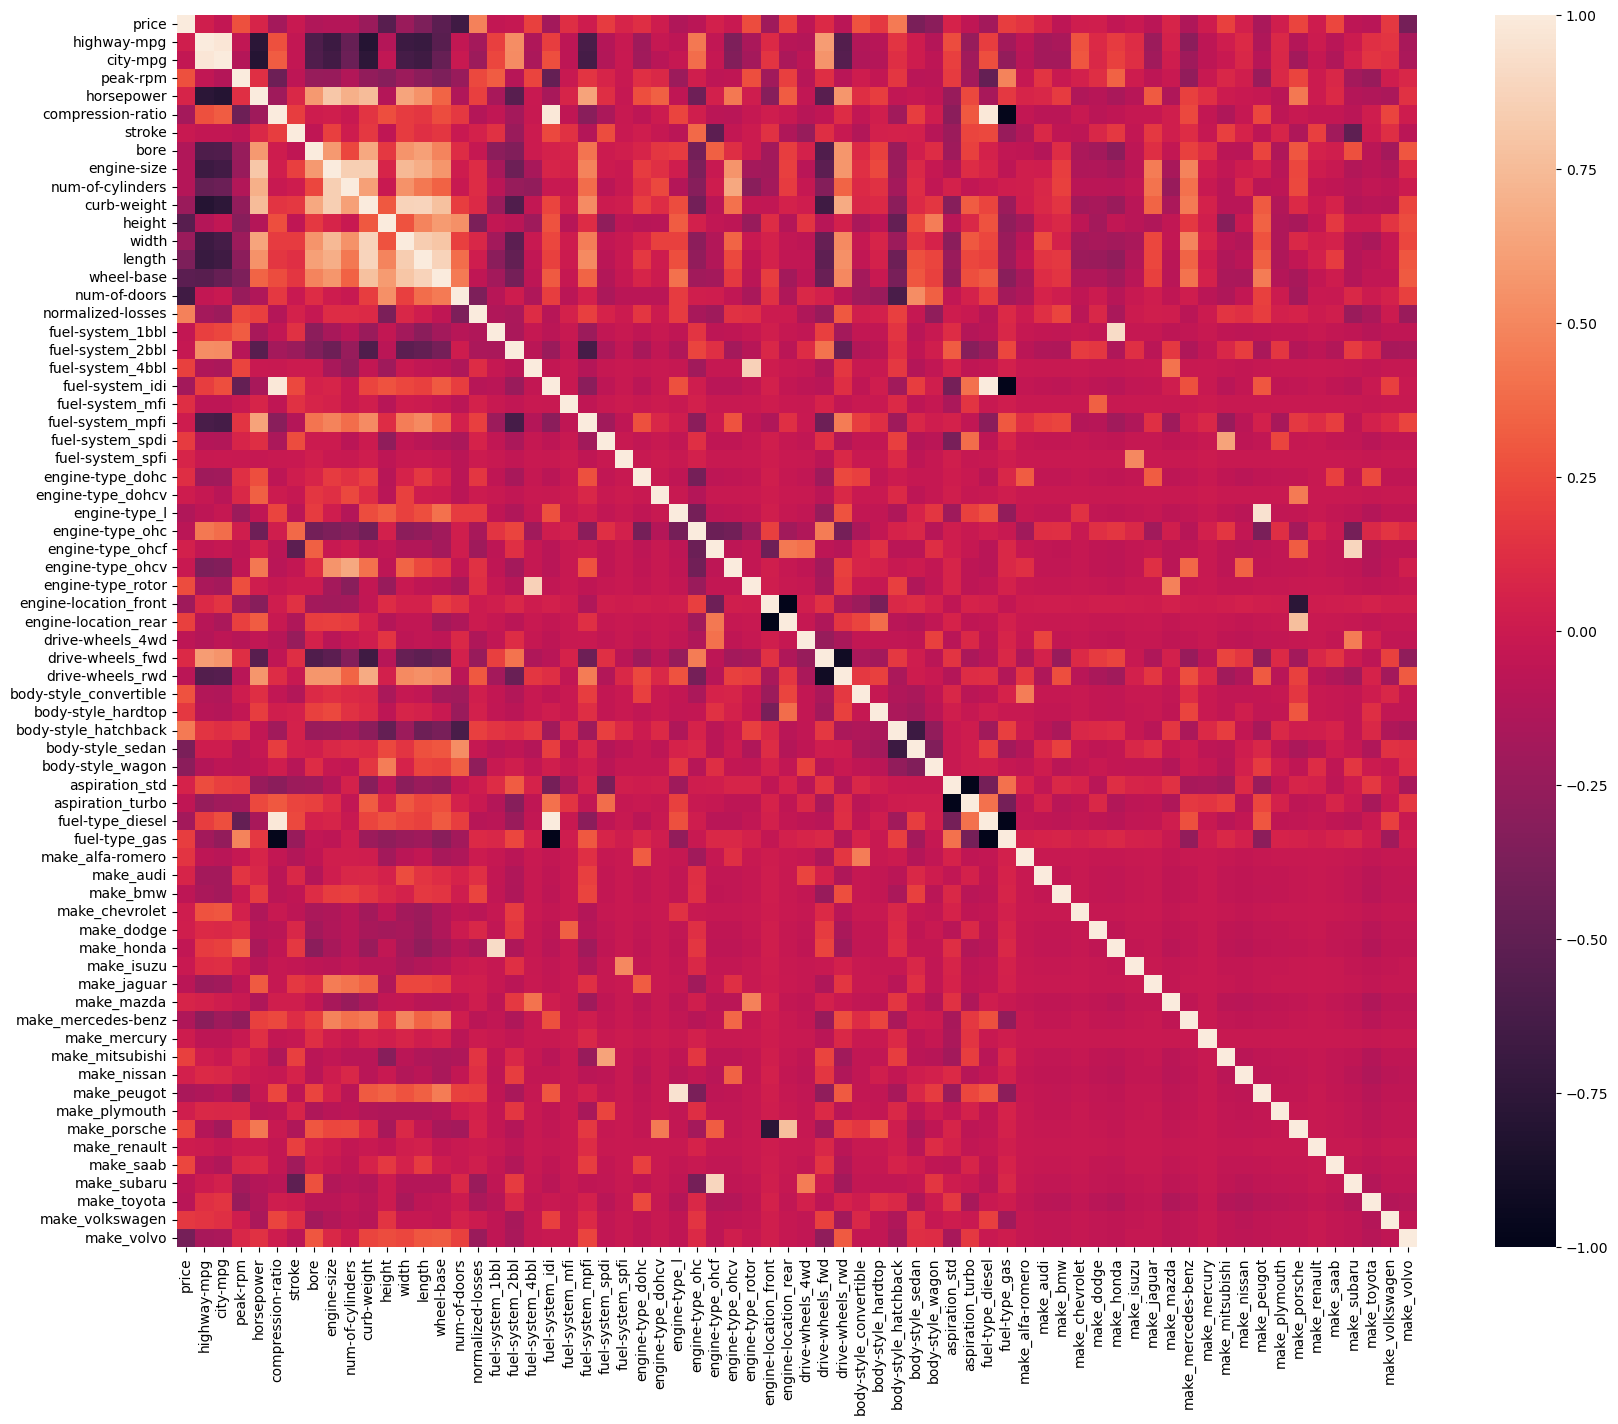

In [ ]:
### 2.1.5. Performing Numerical and Visualizing Correlation Analysis
## Numerical Correlation Analysis
correlation_matrix = automobile_df.corr(numeric_only=True).round(2)
correlation_matrix['price']

## Visual Correlation Analysis
plt.figure(figsize=(20,16))
sns.heatmap(data=correlation_matrix)
plt.show()

In [27]:
### 2.1.6. Identifying a few important attributes
correlation_matrix['price']

features = ['engine-size', 'curb-weight', 'horsepower', 'width', 'highway-mpg', 'city-mpg']
x = x_std[features]

In [31]:
### 2.1.7. Splitting data into training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5) 

### 2.2. Model Construction
In this step, we are proceeding to the model contstuction of the Stochastic Gradient Descent (SGDRegressor). In this model construction, we will be importing the [SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) library from [Scikit-learn](https://scikit-learn.org/stable/).

In this section, we will be performing regularization using hyperparameters and recording results.

In [ ]:
### 2.2.1. Setting up SGDRegressor Model
sgd = SGDRegressor(max_iter = 1000, tol=1e-3)
sgd.fit(x_train, y_train)

SGDRegressor()

In [57]:
### 2.2.2. Initial SGDRegressor Results (Before Tuning)
print(sgd.coef_)
print(sgd.intercept_)
print(sgd.score(x_test, y_test))

[-0.01997133 -0.43945026  0.44443646 -0.29892885  0.03133707 -0.28707546]
[0.86668165]
0.18742954318259264


In [41]:
## 2.2.2.1 Calculating Evaluation metrics
y_pred = sgd.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, mae, evs, r2

(1.3177079507937257,
 0.862358120398032,
 0.20438567395053064,
 0.18742954318259264)

In [ ]:
### 2.2.3. Tuning Hyperparameters
results = []

penalties = ['l1', 'l2', 'elasticnet']
alphas = [0.0001, 0.001, 0.01, 0.1]
l1_ratios = [0.15, 0.5, 0.85]
learning_rates = ['constant', 'invscaling']
max_iters = [1000, 2000]
losses = ['squared_error', 'huber']

for penalty in penalties:
    for alpha in alphas:
        for l1_ratio in l1_ratios:
            for learning_rate in learning_rates:
                for max_iter in max_iters:
                    for loss in losses:
                        sgd_tuned = SGDRegressor (
                            penalty = penalty, alpha = alpha, l1_ratio = l1_ratio,
                            learning_rate = learning_rate, max_iter = max_iter, loss = loss,
                            eta0 = 0.01, tol = 1e-3
                        )
                        
                        sgd_tuned.fit(x_train, y_train)

                        y_train_pred = sgd_tuned.predict(x_train)
                        y_test_pred = sgd_tuned.predict(x_test)


                        results.append({
                            'penalty': penalty, 'alpha': alpha, 'l1_ratio': l1_ratio,
                            'learning_rate': learning_rate, 'max_iter': max_iter, 'loss': loss,
                            'train_mse': mean_squared_error(y_train, y_train_pred),
                            'test_mse': mean_squared_error(y_test, y_test_pred),
                            'train_r2': r2_score(y_train, y_train_pred),
                            'test_r2': r2_score(y_test, y_test_pred),
                            'test_mae': mean_absolute_error(y_test, y_test_pred),
                            'test_evs': explained_variance_score(y_test, y_test_pred),
                        })

results_df = pd.DataFrame(results)


## 2.2.3.1. Figuring out which combination of hyper-parameters works best for our dataset
results_df # total 288 rows

,penalty,alpha,l1_ratio,learning_rate,max_iter,loss,train_mse,test_mse,train_r2,test_r2,test_mae,test_evs
0,l1,0.0001,0.15,constant,1000,squared_error,1.220336,1.361924,0.196402,0.160163,0.881336,1.851711e-01
1,l1,0.0001,0.15,constant,1000,huber,1.390606,1.340085,0.084278,0.173631,0.868089,1.757658e-01
2,l1,0.0001,0.15,constant,2000,squared_error,1.255200,1.429983,0.173444,0.118195,0.914572,1.404822e-01
3,l1,0.0001,0.15,constant,2000,huber,1.389032,1.339373,0.085315,0.174070,0.868227,1.761930e-01
4,l1,0.0001,0.15,invscaling,1000,squared_error,1.219323,1.312608,0.197069,0.190575,0.861229,2.082236e-01
5,l1,0.0001,0.15,invscaling,1000,huber,2.114234,1.959323,-0.392235,-0.208225,1.108587,3.390503e-02
6,l1,0.0001,0.15,invscaling,2000,squared_error,1.217761,1.298217,0.198098,0.199448,0.857137,2.173985e-01
7,l1,0.0001,0.15,invscaling,2000,huber,2.111451,1.956408,-0.390402,-0.206428,1.107941,3.482642e-02
8,l1,0.0001,0.50,constant,1000,squared_error,1.214051,1.233388,0.200541,0.239426,0.843599,2.528189e-01
9,l1,0.0001,0.50,constant,1000,huber,1.387328,1.341834,0.086437,0.172552,0.871677,1.747957e-01
